WEATHER DATA ANALYTICS SYSTEM

Original Dataset Shape: (362, 5)

First 5 Rows:
         Date       City  Temperature  Humidity Weather
0  2026-07-01      Delhi         30.9      40.0  Cloudy
1  2026-07-01     Mumbai         27.9      58.0   Rainy
2  2026-07-01  Bengaluru         29.9      44.0   Sunny
3  2026-07-01    Chennai         25.3      57.0  Cloudy
4  2026-07-01    Kolkata         35.5      97.0   Rainy

-----------------------------------------------------------------
DATA CLEANING
-----------------------------------------------------------------

Missing Values Before Cleaning:
Date           0
City           0
Temperature    1
Humidity       1
Weather        1
dtype: int64

Duplicate Rows Removed: 2

Missing Values After Cleaning:
Date           0
City           0
Temperature    0
Humidity       0
Weather        0
dtype: int64

-----------------------------------------------------------------
AVERAGE TEMPERATURE PER CITY
------------------------------------------------------

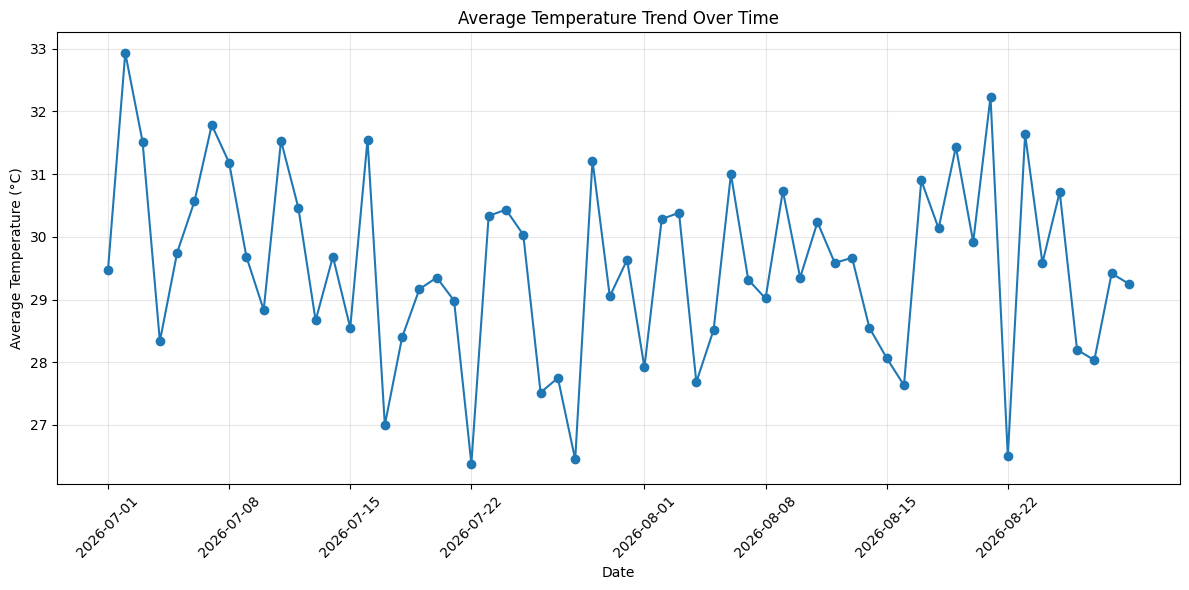

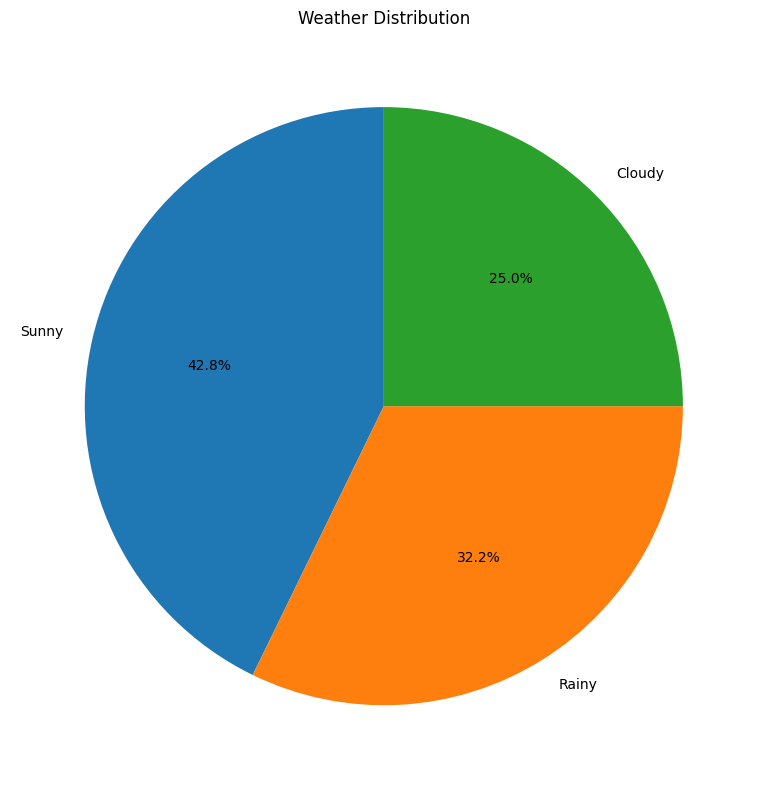

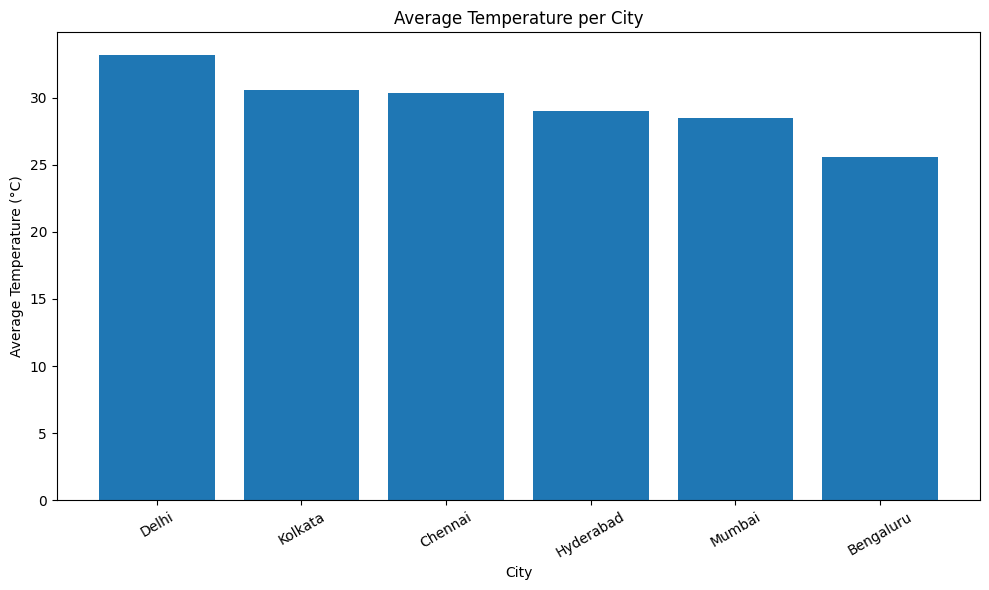


-----------------------------------------------------------------
BONUS: MOVING AVERAGE TEMPERATURE PREDICTION
-----------------------------------------------------------------
Predicted Tomorrow's Temperature: 29.55°C

FINAL SUMMARY
Total Weather Records: 360
Number of Cities: 6
Hottest City: Delhi (33.20°C)
Coldest City: Bengaluru (25.58°C)
Rainy Days/Records: 116
Sunny Days/Records: 154
Predicted Tomorrow Temperature: 29.55°C

Generated Files:
- temperature_trend.png
- weather_distribution.png
- average_temperature_city.png
- final_weather_report.csv

Project completed successfully!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("weather_data.csv")

print("=" * 65)
print("WEATHER DATA ANALYTICS SYSTEM")
print("=" * 65)

print("\nOriginal Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())


print("\n" + "-" * 65)
print("DATA CLEANING")
print("-" * 65)

print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())

duplicates = df.duplicated().sum()
df = df.drop_duplicates()

df["Temperature"] = df["Temperature"].fillna(df["Temperature"].median())
df["Humidity"] = df["Humidity"].fillna(df["Humidity"].median())
df["Weather"] = df["Weather"].fillna(df["Weather"].mode()[0])

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print("\nDuplicate Rows Removed:", duplicates)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())




city_average = (
    df.groupby("City")["Temperature"]
    .mean()
    .sort_values(ascending=False)
)

print("\n" + "-" * 65)
print("AVERAGE TEMPERATURE PER CITY")
print("-" * 65)

print(city_average.round(2))



hottest_city = city_average.idxmax()
hottest_temp = city_average.max()

coldest_city = city_average.idxmin()
coldest_temp = city_average.min()

print(f"\nHottest City: {hottest_city} ({hottest_temp:.2f}°C)")
print(f"Coldest City: {coldest_city} ({coldest_temp:.2f}°C)")


rainy_days = (df["Weather"] == "Rainy").sum()
sunny_days = (df["Weather"] == "Sunny").sum()

print(f"\nRainy Days/Records: {rainy_days}")
print(f"Sunny Days/Records: {sunny_days}")



daily_temperature = df.groupby("Date")["Temperature"].mean()

plt.figure(figsize=(12, 6))

plt.plot(
    daily_temperature.index,
    daily_temperature.values,
    marker="o",
    linewidth=1.5
)

plt.title("Average Temperature Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Average Temperature (°C)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("temperature_trend.png", dpi=300)
plt.show()


weather_distribution = df["Weather"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    weather_distribution.values,
    labels=weather_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Weather Distribution")
plt.tight_layout()

plt.savefig("weather_distribution.png", dpi=300)
plt.show()


plt.figure(figsize=(10, 6))

plt.bar(
    city_average.index,
    city_average.values
)

plt.title("Average Temperature per City")
plt.xlabel("City")
plt.ylabel("Average Temperature (°C)")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig("average_temperature_city.png", dpi=300)
plt.show()



window_size = 7

predicted_tomorrow_temp = daily_temperature.tail(window_size).mean()

print("\n" + "-" * 65)
print("BONUS: MOVING AVERAGE TEMPERATURE PREDICTION")
print("-" * 65)

print(
    f"Predicted Tomorrow's Temperature: "
    f"{predicted_tomorrow_temp:.2f}°C"
)


df["City_Average_Temperature"] = df["City"].map(city_average)

df["Temperature_Deviation"] = (
    df["Temperature"]
    - df["City_Average_Temperature"]
).round(2)

df["Weather_Category"] = df["Weather"]

final_report = df.sort_values(["Date", "City"])

final_report.to_csv(
    "final_weather_report.csv",
    index=False
)



print("\n" + "=" * 65)
print("FINAL SUMMARY")
print("=" * 65)

print(f"Total Weather Records: {len(df)}")
print(f"Number of Cities: {df['City'].nunique()}")
print(f"Hottest City: {hottest_city} ({hottest_temp:.2f}°C)")
print(f"Coldest City: {coldest_city} ({coldest_temp:.2f}°C)")
print(f"Rainy Days/Records: {rainy_days}")
print(f"Sunny Days/Records: {sunny_days}")
print(
    f"Predicted Tomorrow Temperature: "
    f"{predicted_tomorrow_temp:.2f}°C"
)

print("\nGenerated Files:")
print("- temperature_trend.png")
print("- weather_distribution.png")
print("- average_temperature_city.png")
print("- final_weather_report.csv")

print("\nProject completed successfully!")